# Baseline Model Evaluation
This notebook evaluates the pre-trained `SamLowe/roberta-base-go_emotions` model to establish a strong baseline for our project. We can later use these results to compare against our own custom-trained models.

In [1]:
"""import warnings
warnings.filterwarnings('ignore')

#%load_ext autoreload
#%autoreload 2

import sys
import os
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from dotenv import load_dotenv
from huggingface_hub import login
import torch
from sklearn.model_selection import train_test_split
import numpy as np
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from torch.utils.data import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
import nltk
from itertools import combinations
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Add the source folder to sys.path so we can import our modules
source_code_path = os.path.abspath('../source')
if source_code_path not in sys.path:
    sys.path.append(source_code_path)

from my_utils import *
from baseline_roberta import *
from general_preprocessing import *
from visualizations import *
from modeling import *"""

"import warnings\nwarnings.filterwarnings('ignore')\n\n#%load_ext autoreload\n#%autoreload 2\n\nimport sys\nimport os\nimport pandas as pd\nfrom sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer\nfrom dotenv import load_dotenv\nfrom huggingface_hub import login\nimport torch\nfrom sklearn.model_selection import train_test_split\nimport numpy as np\nfrom vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer\nfrom torch.utils.data import Dataset\nfrom transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments\nimport nltk\nfrom itertools import combinations\nimport pandas as pd\nimport numpy as np\nimport seaborn as sns\nimport matplotlib.pyplot as plt\nfrom sklearn.model_selection import train_test_split\n\n# Add the source folder to sys.path so we can import our modules\nsource_code_path = os.path.abspath('../source')\nif source_code_path not in sys.path:\n    sys.path.append(source_code_path)\n\nfrom my_utils impor

USING GOOGLE COLAB

In [2]:
!pip install emoji
!pip install unidecode
!pip install gensim
!pip install Levenshtein
!pip install jellyfish
!pip install vaderSentiment

In [3]:
import sys
import os
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from dotenv import load_dotenv
from huggingface_hub import login
import torch
from sklearn.model_selection import train_test_split
import numpy as np
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from torch.utils.data import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
import nltk
from itertools import combinations
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from google.colab import drive
from torch.utils.data import Dataset

In [4]:
drive.mount('/content/drive')

# Copy your entire project to /content/ailab if not already there
if not os.path.exists('/content/ailab'):
    print("Copying files from Drive...")
    !cp -r "/content/drive/MyDrive/ailab" /content/
    print("Files copied!")
else:
    print("Files already exist in /content/ailab")

# Go to the ailab directory (this becomes your project root)
os.chdir('/content/ailab')
print(f"📁 Current directory: {os.getcwd()}")

# Create symlinks to make relative paths work with your existing code
!ln -sf /content/ailab/data ./data
!ln -sf /content/ailab/source ./source
!ln -sf /content/ailab/notebooks ./notebooks

# Create necessary directories
!mkdir -p /content/results
!mkdir -p /content/wordclouds

# Verify everything works
print("\nVerifying setup:")
print(f"data folder: {os.path.exists('./data')}")
print(f"source folder: {os.path.exists('./source')}")
print(f"notebooks folder: {os.path.exists('./notebooks')}")

# Check for CSV files
import glob
csv_files = glob.glob('./data/*.csv')
if csv_files:
    print(f"CSV files found: {[os.path.basename(f) for f in csv_files]}")
else:
    print("No CSV files found in ./data/")

print("\nSetup complete! Your environment is ready.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files already exist in /content/ailab
📁 Current directory: /content/ailab

Verifying setup:
data folder: True
source folder: True
notebooks folder: True
CSV files found: ['GoEmotions.csv', 'goemotions_multilabel.csv']

Setup complete! Your environment is ready.


In [5]:
import sys

# Add the source folder (where your .py files actually are)
sys.path.append('/content/ailab/source')

# Also add parent folder (optional)
sys.path.append('/content/ailab')

# Now import all your modules
from my_utils import *
from baseline_roberta import *
from general_preprocessing import *
from modeling import *
from visualizations import *
from sentiment_analysis import *

print("All imports successful!")

All imports successful!


In [6]:
from dotenv import load_dotenv
import os
from huggingface_hub import login

load_dotenv()

# Get the token
token = os.getenv('HUGGINGFACE_TOKEN')

if token:
    print(f"Token loaded: {token[:10]}...{token[-5:]}")  # Shows partial token    
else:
    print("No Hugging Face token found in .env (optional)")

No Hugging Face token found in .env (optional)


In [7]:
# Log in with your Hugging Face token
# You can get your token at: https://huggingface.co/settings/tokens
login(token=os.getenv('HUGGINGFACE_TOKEN'))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


### 1. Load the Dataset

As seen in the exploration notebook, since the goal is to predict the emotions of a text based ONLY on the text itself, from now on we will only use the aggeregated dataset, which contains the text and the 28 emotion labels. The original dataset contains also other columns (e.g., source, author, etc.) that we will not use for our task. This new version of the dataset, has also in account that the problem is multilabeled, meaning that some texts have multiple emotions associated with it.

In [8]:
# Load the dataset using the utility function
dataset_original = load_dataset('/content/ailab/data/goemotions_multilabel.csv')

# Display the first few rows to verify it loaded correctly
dataset_original.head()

,text,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,"""If you don't wear BROWN AND ORANGE...YOU DON...",0,0,1,1,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
1,"""What do Scottish people look like?"" How I wo...",0,0,0,0,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,0
2,"### A surprise, to be sure, but a welcome one",0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,"'*Pray*, v. To ask that the laws of the unive...",0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,">it'll get invaded by tankie, unfortunately. ...",0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [9]:
dataset = dataset_original.copy()

## <font color='#BFD72F' size=6>2 Modeling</font> <a class="anchor" id="4"></a>
  
[Back to TOC](toc)

After exploring the dataset, and having our pipeline for preprocessing created, we can move on to actually testing different models and understand how well they can predict the emotions of the texts.

To understand how different preprocessing techniques affect the performance of the model, we will apply three different preprocessings, and use these 3 versions of the text throughout the rest of the project.

### <font color='#BFD72F' size=6>2.1 Creating preprocessed versions</font> <a class="anchor" id="2.1"></a>
  
[Back to TOC](toc)

In [10]:
import nltk
nltk.download('punkt_tab', quiet=False)
nltk.download('punkt', quiet=False)
nltk.download('stopwords', quiet=False)
nltk.download('wordnet', quiet=False)
nltk.download('averaged_perceptron_tagger', quiet=False)
nltk.download('averaged_perceptron_tagger_eng', quiet=False)
nltk.download('omw-1.4', quiet=False)

print("NLTK resources downloaded!")

NLTK resources downloaded!


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [11]:
# Text with translated emojis, hastags, urls (basically the minimal preprocessing to be done, that the allows the model to fully understand every component of the text, without taking the 'emotion' out of it. ) 
dataset['01_minimal_preprocessing'] = dataset['text'].apply(
    lambda x: main_pipeline(
        raw_text=x,
        no_emojis=True,             
        no_hashtags=True,           
        hashtag_retain_words=True,  
        no_newlines=True,           
        no_urls=True,
        no_punctuation=False,  
        no_stopwords=False,
        custom_stopwords=[],
        stopwords_tokeep=[],
        convert_diacritics=False,
        lowercase=False,
        lemmatized=False,
        list_pos=[],
        pos_tags_list='no_pos',
        tokenized_output=False,
        stemmed=False,
        treat_repeated_chars=False
    )
)

In [12]:
# Medium Preprocessing: Text with translated emojis, hastags, urls, punctuation removed, stopwords removed, diacritics converted, lowercased, lemmatized, and repeated characters treated
dataset['02_medium_preprocessing'] = dataset['01_minimal_preprocessing'].apply(
    lambda x: main_pipeline(
        raw_text=x,
        no_emojis=True,             
        no_hashtags=True,           
        hashtag_retain_words=True,  
        no_newlines=True,           
        no_urls=True,
        no_punctuation=True,  
        no_stopwords=False,
        custom_stopwords=[],
        stopwords_tokeep=[],
        convert_diacritics=False,
        lowercase=True,
        lemmatized=False,
        list_pos=[],
        pos_tags_list='no_pos',
        tokenized_output=False,
        stemmed=False,
        treat_repeated_chars=False
    )
)

In [13]:
# Harsh Preprocessing: Text with translated emojis, hastags, urls, punctuation removed, stopwords removed, diacritics converted, lowercased, lemmatized, and repeated characters treated
dataset['03_harsh_preprocessing'] = dataset['02_medium_preprocessing'].apply(
    lambda x: main_pipeline(
        raw_text=x,
        no_emojis=True,             
        no_hashtags=True,           
        hashtag_retain_words=True,  
        no_newlines=True,           
        no_urls=True,
        no_punctuation=True,  
        no_stopwords=True,
        custom_stopwords=[],
        stopwords_tokeep=[],
        convert_diacritics=False,
        lowercase=True,
        lemmatized=False,
        list_pos=[],
        pos_tags_list='no_pos',
        tokenized_output=False,
        stemmed=False,
        treat_repeated_chars=False
    )
)

In [14]:
# Follow an example
print("Original Text Sample:\n")
print(dataset[['text']].iloc[818].values)

print("\nMinimal Preprocessing Sample:\n")
print(dataset[['01_minimal_preprocessing']].iloc[818].values)

print("\nMedium Preprocessing Sample:\n")
print(dataset[['02_medium_preprocessing']].iloc[818].values)

print("\nHarsh Preprocessing Sample:\n")
print(dataset[['03_harsh_preprocessing']].iloc[818].values)

Original Text Sample:

["/uj I would've thought this was pics had it not been for your commie t"]

Minimal Preprocessing Sample:

['/uj I would have thought this was pics had it not been for your commie t']

Medium Preprocessing Sample:

['uj i would have thought this was pics had it not been for your commie t']

Harsh Preprocessing Sample:

['uj would thought pics commie']


Just as some final exploration we will see the most common words in the 3 different preprocessings.

In [15]:
# Analyze Minimal preprocessing
vectorizer = CountVectorizer(max_df=0.8, min_df=5)
X_minimal = vectorizer.fit_transform(dataset['01_minimal_preprocessing'])
words_minimal = vectorizer.get_feature_names_out()
total_counts_minimal = X_minimal.sum(axis=0).A1
df_words_minimal = pd.DataFrame({'word': words_minimal, 'count': total_counts_minimal}).sort_values(by='count', ascending=False)
print("Top 10 words (Minimal preprocessing):")
print(df_words_minimal.head(10))

# Analyze Medium preprocessing
X_medium = vectorizer.fit_transform(dataset['02_medium_preprocessing'])
words_medium = vectorizer.get_feature_names_out()
total_counts_medium = X_medium.sum(axis=0).A1
df_words_medium = pd.DataFrame({'word': words_medium, 'count': total_counts_medium}).sort_values(by='count', ascending=False)
print("\nTop 10 words (Medium preprocessing):")
print(df_words_medium.head(10))

# Analyze Harsh preprocessing
X_harsh = vectorizer.fit_transform(dataset['03_harsh_preprocessing'])
words_harsh = vectorizer.get_feature_names_out()
total_counts_harsh = X_harsh.sum(axis=0).A1
df_words_harsh = pd.DataFrame({'word': words_harsh, 'count': total_counts_harsh}).sort_values(by='count', ascending=False)
print("\nTop 10 words (Harsh preprocessing):")
print(df_words_harsh.head(10))

Top 10 words (Minimal preprocessing):
      word  count
6880   the  24085
3674    is  18188
6984    to  17015
7725   you  15321
3687    it  14492
6878  that  12998
364    and  12091
4617   not  10791
4491  name  10454
4683    of   9569

Top 10 words (Medium preprocessing):
      word  count
6859   the  24082
3665    is  18186
6962    to  17012
7698   you  15312
3678    it  14472
6857  that  12982
372    and  12076
4602   not  10787
4478  name  10446
4667    of   9569

Top 10 words (Harsh preprocessing):
        word  count
4404    name  10446
3912    like   4412
7503   would   3282
2916     get   2485
4632     one   2457
4007    love   2413
4860  people   2363
2976    good   2273
5416  really   1958
6774   think   1941


Word cloud saved to wordclouds/01_minimal_preprocessing.png


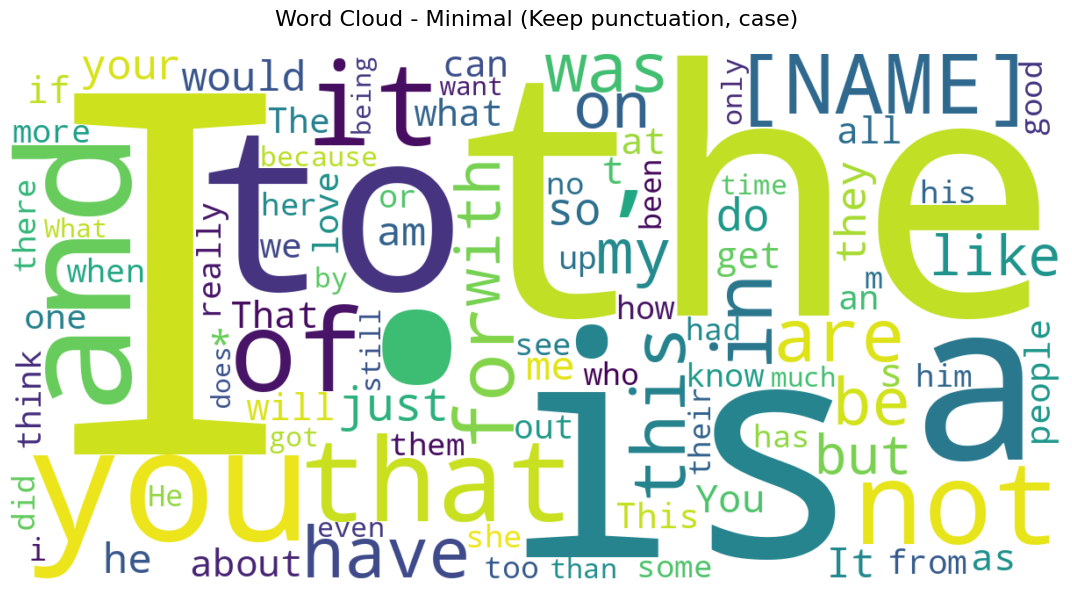

Word cloud saved to wordclouds/02_medium_preprocessing.png


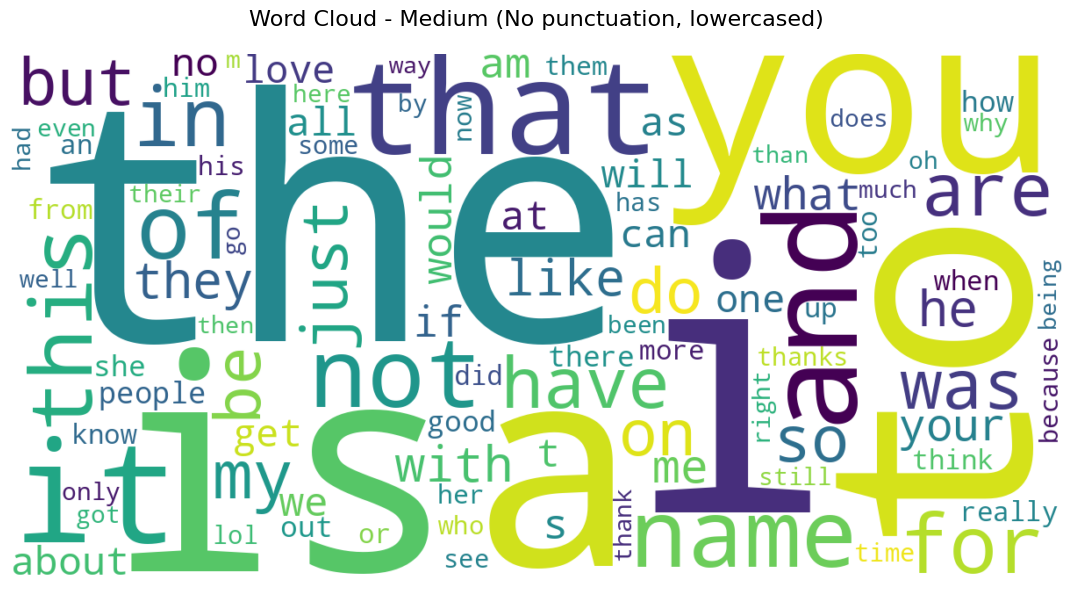

Word cloud saved to wordclouds/03_harsh_preprocessing.png


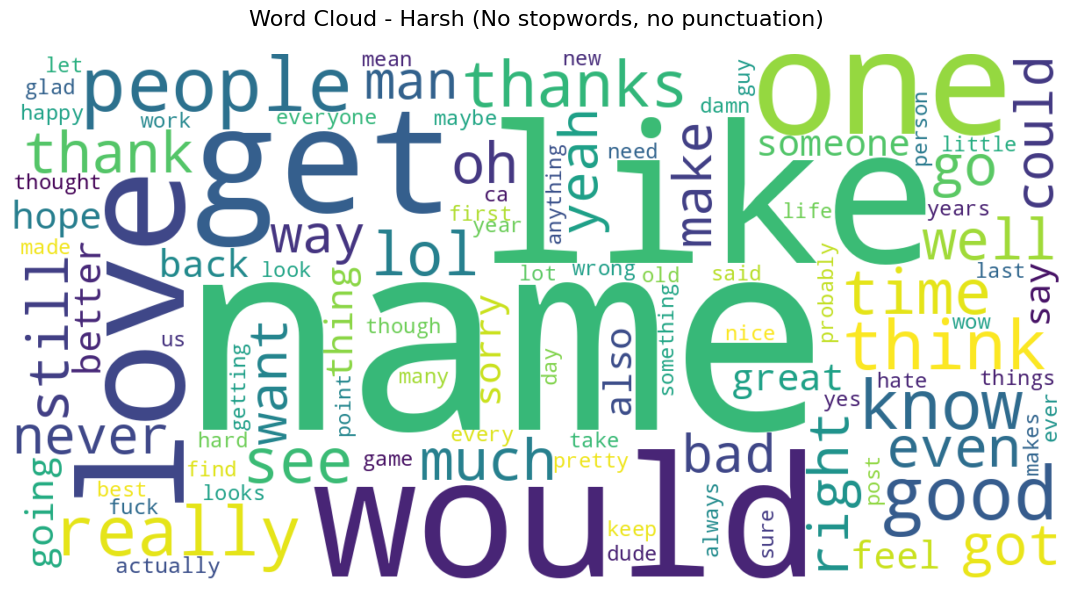

In [16]:
# Define your preprocessing versions
preprocessing_cols = {
    '01_minimal_preprocessing': 'Minimal (Keep punctuation, case)',
    '02_medium_preprocessing': 'Medium (No punctuation, lowercased)',
    '03_harsh_preprocessing': 'Harsh (No stopwords, no punctuation)'
}

# Generate word clouds for all versions
for col, description in preprocessing_cols.items():
    wordcloud_from_text(
        dataset[col],
        title=f"Word Cloud - {description}",
        max_words=100,
        colormap='viridis',
        save_path=f'wordclouds/{col}.png'
    )

It is expected that the more preprocessing we do the worse the model will perform since this tasks constitutes in classifing the emotions of the text, which is normally deeply correlated to punctuation, stopwords, and repeated characters. 

### 2. Apply the Baseline Model
Since evaluating all 200,000+ rows takes a significant amount of time, we first test it on a small sample of 100 rows.

We will use multiple models to evaluate the impact of different preprocessing techniques on the performance of emotion classification. The models we will use include:

In [17]:
MODELS = {
    'roberta_baseline': 'SamLowe/roberta-base-go_emotions',
    'bert_baseline': 'monologg/bert-base-cased-goemotions-original',
    'ekman_baseline': 'bhadresh-savani/bert-base-uncased-emotion'
}

In [18]:
experiments = [
    # (text_column, model_key, output_column_name)
    ('01_minimal_preprocessing', 'roberta_baseline', 'pred_roberta_minimal'),
    ('02_medium_preprocessing', 'roberta_baseline', 'pred_roberta_medium'),
    ('03_harsh_preprocessing', 'roberta_baseline', 'pred_roberta_harsh'), 
    ('01_minimal_preprocessing', 'bert_baseline', 'pred_bert_minimal'),
    ('02_medium_preprocessing', 'bert_baseline', 'pred_bert_medium'),
    ('03_harsh_preprocessing', 'bert_baseline', 'pred_bert_harsh'),
    ('01_minimal_preprocessing', 'ekman_baseline', 'pred_ekman_minimal'),
    ('02_medium_preprocessing', 'ekman_baseline', 'pred_ekman_medium'),
    ('03_harsh_preprocessing', 'ekman_baseline', 'pred_ekman_harsh')
]

In [19]:
# Identify emotion columns
emotion_cols = [
    col for col in dataset.columns
    if col not in ['text', '01_minimal_preprocessing', '02_medium_preprocessing', '03_harsh_preprocessing']
    and not col.startswith('pred_')
]

# Create a new column with the list of true emotions for each row
dataset['true_emotions_label'] = dataset[emotion_cols].apply(
    lambda row: [col for col, val in row.items() if val == 1],
    axis=1
)

print(dataset[['text', 'true_emotions_label']].head())

                                                text  \
0   "If you don't wear BROWN AND ORANGE...YOU DON...   
1   "What do Scottish people look like?" How I wo...   
2     ### A surprise, to be sure, but a welcome one    
3   '*Pray*, v. To ask that the laws of the unive...   
4   >it'll get invaded by tankie, unfortunately. ...   

                               true_emotions_label  
0  [anger, annoyance, approval, optimism, neutral]  
1                                [curiosity, love]  
2                                       [surprise]  
3                                        [neutral]  
4                                        [neutral]  


In [20]:
test_data_fixed = dataset.head(1000).copy()
train_val_data = dataset.iloc[1000:].copy()

In [21]:
for text_col, model_key, output_col in experiments:
    # Print a header for clarity
    print(f"\n{'='*60}")
    print(f"Running: {model_key} on {text_col}")
    print(f"Output column: {output_col}")
    print('='*60)
    
    test_data_fixed = predict_with_model(
        df=test_data_fixed,
        text_column=text_col,
        model_name=MODELS[model_key],
        output_column=output_col,
        threshold=0.5
    )

print("\n" + "="*60)
print("ALL PREDICTION COLUMNS ADDED:")
print("="*60)
pred_cols = [col for col in test_data_fixed.columns if col.startswith('pred_')]
for col in pred_cols:
    print(f"  {col}")


Running: roberta_baseline on 01_minimal_preprocessing
Output column: pred_roberta_minimal
No token found
Loading model: SamLowe/roberta-base-go_emotions...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Generating predictions for 1000 rows...


Predicting with pred_roberta_minimal: 100%|██████████| 1000/1000 [00:10<00:00, 94.49it/s]


 Predictions saved to column: 'pred_roberta_minimal'

Running: roberta_baseline on 02_medium_preprocessing
Output column: pred_roberta_medium
No token found
Loading model: SamLowe/roberta-base-go_emotions...


...

 Predictions saved to column: 'pred_ekman_medium'

Running: ekman_baseline on 03_harsh_preprocessing
Output column: pred_ekman_harsh
No token found
Loading model: bhadresh-savani/bert-base-uncased-emotion...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Generating predictions for 1000 rows...


Predicting with pred_ekman_harsh: 100%|██████████| 1000/1000 [00:09<00:00, 102.44it/s]

 Predictions saved to column: 'pred_ekman_harsh'

ALL PREDICTION COLUMNS ADDED:
  pred_roberta_minimal
  pred_roberta_medium
  pred_roberta_harsh
  pred_bert_minimal
  pred_bert_medium
  pred_bert_harsh
  pred_ekman_minimal
  pred_ekman_medium
  pred_ekman_harsh


In [22]:
test_data_fixed[['pred_roberta_minimal', 'pred_roberta_medium', 'pred_roberta_harsh']].head()

,pred_roberta_minimal,pred_roberta_medium,pred_roberta_harsh
0,"{'neutral': 1, 'annoyance': 0, 'disapproval': ...","{'neutral': 1, 'disapproval': 0, 'approval': 0...","{'neutral': 1, 'disapproval': 0, 'approval': 0..."
1,"{'love': 1, 'curiosity': 0, 'desire': 0, 'neut...","{'love': 1, 'curiosity': 0, 'desire': 0, 'conf...","{'love': 1, 'neutral': 0, 'approval': 0, 'admi..."
2,"{'surprise': 1, 'excitement': 0, 'approval': 0...","{'surprise': 1, 'excitement': 0, 'admiration':...","{'surprise': 1, 'neutral': 0, 'excitement': 0,..."
3,"{'neutral': 1, 'disapproval': 0, 'annoyance': ...","{'neutral': 1, 'annoyance': 0, 'disapproval': ...","{'neutral': 1, 'disapproval': 0, 'annoyance': ..."
4,"{'neutral': 1, 'approval': 0, 'realization': 0...","{'neutral': 1, 'approval': 0, 'realization': 0...","{'neutral': 1, 'disapproval': 0, 'approval': 0..."


ERROR ANALYSIS

In [23]:
true_dict = test_data_fixed[emotion_cols].iloc[0].to_dict()
pred_dict = test_data_fixed['pred_roberta_minimal'].iloc[0]

print("TRUE:")
print(true_dict)
print("\nPRED:")
print(pred_dict)

print("\nVERGLEICH:")
for emotion in emotion_cols:
    true_val = true_dict[emotion]
    pred_val = pred_dict[emotion]
    match = "✅" if true_val == pred_val else "❌"
    print(f"{match} {emotion}: true={true_val}, pred={pred_val}")

TRUE:
{'admiration': 0, 'amusement': 0, 'anger': 1, 'annoyance': 1, 'approval': 1, 'caring': 0, 'confusion': 0, 'curiosity': 0, 'desire': 0, 'disappointment': 0, 'disapproval': 0, 'disgust': 0, 'embarrassment': 0, 'excitement': 0, 'fear': 0, 'gratitude': 0, 'grief': 0, 'joy': 0, 'love': 0, 'nervousness': 0, 'optimism': 1, 'pride': 0, 'realization': 0, 'relief': 0, 'remorse': 0, 'sadness': 0, 'surprise': 0, 'neutral': 1}

PRED:
{'neutral': 1, 'annoyance': 0, 'disapproval': 0, 'approval': 0, 'anger': 0, 'realization': 0, 'disappointment': 0, 'optimism': 0, 'caring': 0, 'amusement': 0, 'disgust': 0, 'desire': 0, 'confusion': 0, 'curiosity': 0, 'sadness': 0, 'admiration': 0, 'joy': 0, 'excitement': 0, 'surprise': 0, 'embarrassment': 0, 'fear': 0, 'love': 0, 'gratitude': 0, 'relief': 0, 'nervousness': 0, 'pride': 0, 'remorse': 0, 'grief': 0}

VERGLEICH:
✅ admiration: true=0, pred=0
✅ amusement: true=0, pred=0
❌ anger: true=1, pred=0
❌ annoyance: true=1, pred=0
❌ approval: true=1, pred=0
✅ c

In [24]:
# Convert prediction dictionaries(binary) to lists(Strings) of predicted emotions and save them in new columns
for col in pred_cols:
    label_col = f"{col}_labels"
    test_data_fixed[label_col] = test_data_fixed[col].apply(prediction_to_labels)

# Display the first few rows of the relevant columns to verify the label conversion
test_data_fixed[['true_emotions_label',
           'pred_roberta_minimal_labels',
           'pred_roberta_medium_labels',
           'pred_roberta_harsh_labels']].head()

,true_emotions_label,pred_roberta_minimal_labels,pred_roberta_medium_labels,pred_roberta_harsh_labels
0,"[anger, annoyance, approval, optimism, neutral]",[neutral],[neutral],[neutral]
1,"[curiosity, love]",[love],[love],[love]
2,[surprise],[surprise],[surprise],[surprise]
3,[neutral],[neutral],[neutral],[neutral]
4,[neutral],[neutral],[neutral],[neutral]


In [25]:
test_data_fixed

,text,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,...,pred_ekman_harsh,pred_roberta_minimal_labels,pred_roberta_medium_labels,pred_roberta_harsh_labels,pred_bert_minimal_labels,pred_bert_medium_labels,pred_bert_harsh_labels,pred_ekman_minimal_labels,pred_ekman_medium_labels,pred_ekman_harsh_labels
0,"""If you don't wear BROWN AND ORANGE...YOU DON...",0,0,1,1,1,0,0,0,0,...,"{'joy': 1, 'anger': 0, 'sadness': 0, 'love': 0...",[neutral],[neutral],[neutral],[annoyance],[neutral],[neutral],[anger],[anger],[joy]
1,"""What do Scottish people look like?"" How I wo...",0,0,0,0,0,0,0,1,0,...,"{'anger': 0, 'joy': 0, 'love': 0, 'fear': 0, '...",[love],[love],[love],[love],[love],[love],[joy],[joy],[]
2,"### A surprise, to be sure, but a welcome one",0,0,0,0,0,0,0,0,0,...,"{'joy': 1, 'love': 0, 'surprise': 0, 'sadness'...",[surprise],[surprise],[surprise],[surprise],[surprise],[surprise],[joy],[joy],[joy]
3,"'*Pray*, v. To ask that the laws of the unive...",0,0,0,0,0,0,0,0,0,...,"{'joy': 1, 'sadness': 0, 'anger': 0, 'fear': 0...",[neutral],[neutral],[neutral],[neutral],[neutral],[neutral],[],[joy],[joy]
4,">it'll get invaded by tankie, unfortunately. ...",0,0,0,0,0,0,0,0,0,...,"{'anger': 1, 'fear': 0, 'love': 0, 'joy': 0, '...",[neutral],[neutral],[neutral],[neutral],[neutral],[neutral],[anger],[anger],[anger]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,350 calories The large is 20 oz and it’s 140 p...,0,0,0,0,0,0,0,0,0,...,"{'joy': 1, 'anger': 0, 'fear': 0, 'surprise': ...",[neutral],[neutral],[neutral],[neutral],[neutral],[neutral],[joy],[joy],[joy]
996,"35k? That's just crazy. Mine was less than 2k,...",0,0,0,0,0,0,0,1,0,...,"{'anger': 1, 'joy': 0, 'fear': 0, 'surprise': ...",[],[],[neutral],[curiosity],[neutral],[neutral],[fear],[fear],[anger]
997,36 and definitely not what I used to be... sti...,0,0,0,0,1,0,0,0,0,...,"{'joy': 1, 'anger': 0, 'sadness': 0, 'love': 0...",[neutral],[neutral],[approval],[neutral],[neutral],[approval],[joy],[joy],[joy]
998,37 and together 12 years. 11 yo kiddo. Thanks ...,0,0,0,0,1,0,0,0,0,...,"{'joy': 1, 'love': 0, 'anger': 0, 'sadness': 0...",[gratitude],[gratitude],[gratitude],[gratitude],[gratitude],[gratitude],[joy],[joy],[joy]


In [26]:
prediction_cols = {
    'Minimal Preprocessing Roberta': 'pred_roberta_minimal',
    'Medium Preprocessing Roberta': 'pred_roberta_medium',
    'Harsh Preprocessing Roberta': 'pred_roberta_harsh',
    'Minimal Preprocessing BERT': 'pred_bert_minimal',
    'Medium Preprocessing BERT': 'pred_bert_medium',
    'Harsh Preprocessing BERT': 'pred_bert_harsh',
    'Minimal Preprocessing Ekman': 'pred_ekman_minimal',
    'Medium Preprocessing Ekman': 'pred_ekman_medium',
    'Harsh Preprocessing Ekman': 'pred_ekman_harsh'
}

print("Prediction columns in the dataset:")
for col in prediction_cols.values():
    print(f"  - {col}")

Prediction columns in the dataset:
  - pred_roberta_minimal
  - pred_roberta_medium
  - pred_roberta_harsh
  - pred_bert_minimal
  - pred_bert_medium
  - pred_bert_harsh
  - pred_ekman_minimal
  - pred_ekman_medium
  - pred_ekman_harsh


In [27]:
comparison_df = create_model_comparison_df(
    df=test_data_fixed,  # or dataset_with_predictions
    emotion_cols=emotion_cols,
    prediction_cols=prediction_cols
)

In [28]:
comparison_df.head

<bound method NDFrame.head of                            model  micro_f1  macro_f1  samples_f1  weighted_f1  \
0  Minimal Preprocessing Roberta  0.450274  0.271344    0.505505     0.400700   
1   Medium Preprocessing Roberta  0.428198  0.269679    0.480395     0.382372   
2    Harsh Preprocessing Roberta  0.425544  0.228792    0.481357     0.355424   
3     Minimal Preprocessing BERT  0.501531  0.346688    0.571834     0.472669   
4      Medium Preprocessing BERT  0.473934  0.325399    0.541779     0.439295   
5       Harsh Preprocessing BERT  0.454444  0.244778    0.522302     0.381060   
6    Minimal Preprocessing Ekman  0.116620  0.058801    0.101971     0.048789   
7     Medium Preprocessing Ekman  0.113419  0.055052    0.100600     0.046099   
8      Harsh Preprocessing Ekman  0.108763  0.053341    0.094974     0.043963   

   exact_match_ratio  hamming_loss  micro_precision  micro_recall  \
0              0.180      0.068107         0.909197      0.299234   
1              0.167 

In [29]:
best_model = comparison_df.loc[comparison_df['macro_f1'].idxmax(), 'model']
best_f1 = comparison_df.loc[comparison_df['macro_f1'].idxmax(), 'macro_f1']
print(f"\n Best model based on Macro F1: {best_model} ({best_f1:.4f})")


 Best model based on Macro F1: Minimal Preprocessing BERT (0.3467)


In [30]:
def build_cooccurrence_table(true_df, pred_series, emotion_cols):
    
    pred_binary = pd.DataFrame(0, index=pred_series.index, columns=emotion_cols)
    for idx, pred in enumerate(pred_series):
        if isinstance(pred, dict):
            for emotion, val in pred.items():
                if emotion in emotion_cols and val == 1:
                    pred_binary.iloc[idx][emotion] = 1

    all_labels = []
    for e in emotion_cols:
        for outcome in ["TP", "FP", "FN"]:
            all_labels.append(f"{e}_{outcome}")

    matrix = pd.DataFrame(0, index=all_labels, columns=all_labels)

    for i in range(len(true_df)):
        true_row = true_df[emotion_cols].iloc[i]
        pred_row = pred_binary.iloc[i]

        row_labels = []
        for e in emotion_cols:
            t = true_row[e]
            p = pred_row[e]
            if p == 1 and t == 1:
                row_labels.append(f"{e}_TP")
            elif p == 1 and t == 0:
                row_labels.append(f"{e}_FP")
            elif p == 0 and t == 1:
                row_labels.append(f"{e}_FN")

        for a, b in combinations(row_labels, 2):
            matrix.loc[a, b] += 1
            matrix.loc[b, a] += 1

    mask = matrix.sum(axis=1) > 0
    matrix = matrix.loc[mask, mask]

    return matrix, pred_binary  # <-- pred_binary auch zurückgeben

# Ausführen
cooc, pred_binary = build_cooccurrence_table(
    true_df=test_data,
    pred_series=test_data["pred_roberta_minimal"],
    emotion_cols=emotion_cols
)


# Tabelle anzeigen
print(cooc)

# Heatmap
plt.figure(figsize=(20, 16))
cooc_masked = cooc.where(cooc > 0)
sns.heatmap(cooc_masked, cmap="YlOrRd", annot=True, fmt=".0f", linewidths=0.5)
plt.title("Co-Occurrence: (Emotion, Outcome) Paare pro Satz")
plt.tight_layout()
plt.show()

NameError: name 'test_data' is not defined

In [ ]:
summary = pd.DataFrame([
    {
        "emotion": e,
        "TP": int(((pred_binary[e] == 1) & (test_data[e] == 1)).sum()),
        "FP": int(((pred_binary[e] == 1) & (test_data[e] == 0)).sum()),
        "FN": int(((pred_binary[e] == 0) & (test_data[e] == 1)).sum()),
        "TN": int(((pred_binary[e] == 0) & (test_data[e] == 0)).sum()),
    }
    for e in emotion_cols
]).set_index("emotion")

print(summary)

                 TP  FP   FN   TN
emotion                          
admiration       37   4   74  885
amusement        36   3   32  929
anger            24   3  105  868
annoyance        16   2  145  837
approval         14   4  161  821
caring           13   1   54  932
confusion         3   1   55  941
curiosity        10   4   81  905
desire            1   2   23  974
disappointment   10   1   92  897
disapproval      15   2  115  868
disgust           8   0   52  940
embarrassment     5   1   16  978
excitement        5   1   82  912
fear              3   0   27  970
gratitude        18   0   25  957
grief             0   0    5  995
joy              24   7   70  899
love             28   2   37  933
nervousness       0   0   16  984
optimism         11   0   63  926
pride             0   0   18  982
realization       5   0   98  897
relief            0   0   15  985
remorse           6   1   11  982
sadness          14   1   44  941
surprise         13   2   63  922
neutral       

: 

: 

In [ ]:
# Every Pair with count > 10
high_cooc = []

for i in range(len(cooc.index)):
    for j in range(i+1, len(cooc.columns)):  # nur oberes Dreieck, keine Duplikate
        val = cooc.iloc[i, j]
        if val > 10:
            high_cooc.append({
                "emotion_outcome_1": cooc.index[i],
                "emotion_outcome_2": cooc.columns[j],
                "count": int(val)
            })

high_cooc_df = pd.DataFrame(high_cooc).sort_values("count", ascending=False)
pd.set_option('display.max_rows', None)
print(high_cooc_df)

    emotion_outcome_1  emotion_outcome_2  count
28        approval_FN         neutral_TP     70
20       annoyance_FN         neutral_TP     51
48     disapproval_FN         neutral_TP     45
29        approval_FN         neutral_FN     43
9            anger_FN       annoyance_FN     42
21       annoyance_FN         neutral_FN     38
13           anger_FN         neutral_TP     37
67     realization_FN         neutral_TP     36
16       annoyance_FN  disappointment_FN     33
38       curiosity_FN         neutral_TP     32
17       annoyance_FN     disapproval_FN     30
58      excitement_FN         neutral_FN     30
18       annoyance_FN         disgust_FN     29
45  disappointment_FN         neutral_TP     28
68     realization_FN         neutral_FN     28
14           anger_FN         neutral_FN     27
49     disapproval_FN         neutral_FN     27
64        optimism_FN         neutral_TP     26
46  disappointment_FN         neutral_FN     26
10           anger_FN  disappointment_FN

: 

: 

In [ ]:
#high_cooc_df.to_excel("cooccurrence_analysis.xlsx", index=False)

: 

: 

In [ ]:
'''prediction_cols = {
    "RoBERTa Baseline": "roberta_baseline_predictions",
    # weitere hier ergänzen z.B.:
    # "RoBERTa Medium": "02_roberta_predictions",
}

rows = []

# True emotions (gleich für alle)
true_counts = test_data[emotion_cols].sum(axis=1)
rows.append({
    "model": "True Labels",
    "Mehr als 1": int((true_counts > 1).sum()),
    "Mehr als 1 (%)": f"{(true_counts > 1).mean() * 100:.1f}%",
    "Mehr als 2": int((true_counts > 2).sum()),
    "Mehr als 2 (%)": f"{(true_counts > 2).mean() * 100:.1f}%",
})

# Pro Prediction Column
for model_name, pred_col in prediction_cols.items():
    # pred_binary aufbauen
    pb = pd.DataFrame(0, index=test_data.index, columns=emotion_cols)
    for idx, pred in enumerate(test_data[pred_col]):
        if isinstance(pred, dict):
            for emotion, val in pred.items():
                if emotion in emotion_cols and val == 1:
                    pb.iloc[idx][emotion] = 1

    pred_counts = pb.sum(axis=1)
    rows.append({
        "model": model_name,
        "Mehr als 1": int((pred_counts > 1).sum()),
        "Mehr als 1 (%)": f"{(pred_counts > 1).mean() * 100:.1f}%",
        "Mehr als 2": int((pred_counts > 2).sum()),
        "Mehr als 2 (%)": f"{(pred_counts > 2).mean() * 100:.1f}%",
    })

cardinality_df = pd.DataFrame(rows).set_index("model")
print(cardinality_df)'''

'prediction_cols = {\n    "RoBERTa Baseline": "roberta_baseline_predictions",\n    # weitere hier ergänzen z.B.:\n    # "RoBERTa Medium": "02_roberta_predictions",\n}\n\nrows = []\n\n# True emotions (gleich für alle)\ntrue_counts = test_data[emotion_cols].sum(axis=1)\nrows.append({\n    "model": "True Labels",\n    "Mehr als 1": int((true_counts > 1).sum()),\n    "Mehr als 1 (%)": f"{(true_counts > 1).mean() * 100:.1f}%",\n    "Mehr als 2": int((true_counts > 2).sum()),\n    "Mehr als 2 (%)": f"{(true_counts > 2).mean() * 100:.1f}%",\n})\n\n# Pro Prediction Column\nfor model_name, pred_col in prediction_cols.items():\n    # pred_binary aufbauen\n    pb = pd.DataFrame(0, index=test_data.index, columns=emotion_cols)\n    for idx, pred in enumerate(test_data[pred_col]):\n        if isinstance(pred, dict):\n            for emotion, val in pred.items():\n                if emotion in emotion_cols and val == 1:\n                    pb.iloc[idx][emotion] = 1\n\n    pred_counts = pb.sum(axis=1

: 

: 

FINE TUNING THE MODEL

Split the data

In [31]:
texts = train_val_data['01_minimal_preprocessing'].tolist()  # or 'text' column
labels = train_val_data[emotion_cols].values  # Already in correct format

# Split into train (80%), validation (10%), and test (10%)
train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, 
    test_size=0.2, 
    random_state=42
)

"""# Split temp into validation (10%) and test (10%)
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, 
    test_size=0.5, 
    random_state=42
)"""

print(f"Data split complete!")
print(f"Train: {len(train_texts)} samples")
print(f"Validation: {len(val_texts)} samples")
#print(f"Test: {len(test_texts)} samples")

Data split complete!
Train: 45385 samples
Validation: 11347 samples


In [32]:
from  transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
# Best model from your baseline (BERT)
model_name = 'monologg/bert-base-cased-goemotions-original'  # Best performer
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(emotion_cols),
    problem_type="multi_label_classification"
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [33]:
train_dataset = GoEmotionsDataset(train_texts, train_labels, tokenizer)
val_dataset = GoEmotionsDataset(val_texts, val_labels, tokenizer)
#test_dataset = GoEmotionsDataset(test_texts, test_labels, tokenizer)


In [34]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,              
    per_device_train_batch_size=16, 
    per_device_eval_batch_size=32,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    push_to_hub=False,
    report_to="none",  
    fp16=torch.cuda.is_available(),  
    dataloader_num_workers=2,
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [35]:
def make_metrics_function(emotion_cols, multilabel_metrics=None):
    """
    Creates a metrics function for Hugging Face Trainer.
    (multilabel_metrics parameter is kept for compatibility but not used)
    """
    def compute_metrics(eval_pred):
        predictions, labels = eval_pred
        
        # Convert logits to probabilities with sigmoid
        probs = 1.0 / (1.0 + np.exp(-predictions))
        
        # Apply threshold of 0.5
        pred_binary = (probs >= 0.5).astype(int)
        
        # Calculate metrics
        metrics = {
            'micro_f1': f1_score(labels, pred_binary, average='micro', zero_division=0),
            'macro_f1': f1_score(labels, pred_binary, average='macro', zero_division=0),
            'weighted_f1': f1_score(labels, pred_binary, average='weighted', zero_division=0),
            'samples_f1': f1_score(labels, pred_binary, average='samples', zero_division=0),
            'hamming_loss': hamming_loss(labels, pred_binary),
            'exact_match': accuracy_score(labels, pred_binary),
            'micro_precision': precision_score(labels, pred_binary, average='micro', zero_division=0),
            'micro_recall': recall_score(labels, pred_binary, average='micro', zero_division=0),
        }
        
        return metrics
    
    return compute_metrics

In [36]:
compute_metrics = make_metrics_function(emotion_cols, multilabel_metrics)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,  # Now this is the actual function
)

In [37]:
trainer.train()

Epoch,Training Loss,Validation Loss,Micro F1,Macro F1,Weighted F1,Samples F1,Hamming Loss,Exact Match,Micro Precision,Micro Recall,Runtime,Samples Per Second,Steps Per Second
1,0.193026,0.186984,0.569059,0.464082,0.544135,0.611702,0.067545,0.174407,0.817883,0.436318,86.355200,131.399000,4.111000
2,0.162154,0.187464,0.598849,0.513697,0.586820,0.633936,0.068860,0.169560,0.740120,0.502864,86.294000,131.492000,4.114000
3,0.132673,0.197901,0.598658,0.522314,0.588554,0.633795,0.070409,0.165066,0.717160,0.513765,86.234300,131.583000,4.117000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=8511, training_loss=0.16542523479562515, metrics={'train_runtime': 3483.276, 'train_samples_per_second': 39.088, 'train_steps_per_second': 2.443, 'total_flos': 3.499243026966e+16, 'train_loss': 0.16542523479562515, 'epoch': 3.0})

In [38]:
#model.save_pretrained('./fine_tuned_goemotions')
#tokenizer.save_pretrained('./fine_tuned_goemotions')

In [40]:
dummy_labels = np.zeros((len(test_data_fixed), len(emotion_cols)))

test_texts_fixed = test_data_fixed['01_minimal_preprocessing'].tolist()
test_dataset_fixed = GoEmotionsDataset(test_texts_fixed, dummy_labels, tokenizer)
test_predictions = trainer.predict(test_dataset_fixed)

# Converting predictions to binary
test_probs = 1.0 / (1.0 + np.exp(-test_predictions.predictions))
test_pred_binary = (test_probs >= 0.5).astype(int)

fine_tuned_predictions = []
for i in range(len(test_pred_binary)):
    pred_dict = {emotion_cols[j]: test_pred_binary[i][j] for j in range(len(emotion_cols))}
    fine_tuned_predictions.append(pred_dict)

In [41]:
test_data_fixed['pred_finetuned_bert_text_only'] = fine_tuned_predictions

test_data_fixed['pred_finetuned_labels'] = test_data_fixed['pred_finetuned_bert_text_only'].apply(prediction_to_labels)

In [42]:
print(f"Length of test_data: {len(test_data_fixed)}")
print(f"Length of test_pred_binary: {len(test_pred_binary)}")

Length of test_data: 1000
Length of test_pred_binary: 1000


In [43]:
test_data_fixed[['true_emotions_label', 'pred_roberta_minimal_labels', 'pred_finetuned_labels']].head()

,true_emotions_label,pred_roberta_minimal_labels,pred_finetuned_labels
0,"[anger, annoyance, approval, optimism, neutral]",[neutral],"[annoyance, disapproval, neutral]"
1,"[curiosity, love]",[love],"[confusion, curiosity, love]"
2,[surprise],[surprise],"[excitement, joy, optimism, surprise]"
3,[neutral],[neutral],[neutral]
4,[neutral],[neutral],[neutral]


In [44]:
y_true = test_data_fixed[emotion_cols].values
y_pred = test_pred_binary

# Calculate metrics
micro_f1 = f1_score(y_true, y_pred, average='micro', zero_division=0)
macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
samples_f1 = f1_score(y_true, y_pred, average='samples', zero_division=0)
hl = hamming_loss(y_true, y_pred)
exact_match = (y_pred == y_true).all(axis=1).mean()

In [63]:
from sklearn.metrics import f1_score


true_labels = test_data_fixed[emotion_cols].values

models_to_evaluate = {
    'RoBERTa (Minimal)': 'pred_roberta_minimal',
    'RoBERTa (Medium)': 'pred_roberta_medium',
    'RoBERTa (Harsh)': 'pred_roberta_harsh',
    'BERT (Minimal)': 'pred_bert_minimal',
    'BERT (Medium)': 'pred_bert_medium',
    'BERT (Harsh)': 'pred_bert_harsh',
    'Ekman (Minimal)': 'pred_ekman_minimal',
    'Ekman (Medium)': 'pred_ekman_medium',
    'Ekman (Harsh)': 'pred_ekman_harsh',
}

comparison_data = []
for model_name, pred_col in models_to_evaluate.items():
    if pred_col in test_data_fixed.columns:
        preds = test_data_fixed[pred_col].apply(
            lambda x: [x.get(emotion, 0) for emotion in emotion_cols]
        )
        pred_array = np.array([list(p) for p in preds])
        
        comparison_data.append({
            'model': model_name,
            'micro_f1': f1_score(true_labels, pred_array, average='micro', zero_division=0),
            'macro_f1': f1_score(true_labels, pred_array, average='macro', zero_division=0),
            'weighted_f1': f1_score(true_labels, pred_array, average='weighted', zero_division=0),
            'samples_f1': f1_score(true_labels, pred_array, average='samples', zero_division=0),
            'hamming_loss': hamming_loss(true_labels, pred_array),
            'exact_match_ratio': (pred_array == true_labels).all(axis=1).mean()
        })

fine_tuned_results = pd.DataFrame([{
    'model': 'Fine-tuned BERT (Text Only)',
    'micro_f1': micro_f1,
    'macro_f1': macro_f1,
    'weighted_f1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
    'samples_f1': samples_f1,
    'hamming_loss': hl,
    'exact_match_ratio': exact_match
}])

comparison_df_updated = pd.DataFrame(comparison_data)
comparison_df_updated = pd.concat([comparison_df_updated, fine_tuned_results], ignore_index=True)

comparison_df_updated = comparison_df_updated.sort_values('weighted_f1', ascending=False)

comparison_df_updated.to_csv('model_comparison_complete.csv', index=False)

# Highlight the best model
best_model = comparison_df_updated.iloc[0]
print(f"\n BEST MODEL: {best_model['model']}")
print(f"   Weighted F1: {best_model['weighted_f1']:.4f}")


 BEST MODEL: Fine-tuned BERT (Text Only)
   Weighted F1: 0.5883


In [46]:
prediction_cols_updated = prediction_cols.copy()  # Start with existing models
prediction_cols_updated['Fine-tuned BERT (Text Only)'] = 'pred_finetuned_bert_text_only'

In [47]:
comparison_df_updated

,model,micro_f1,macro_f1,weighted_f1,samples_f1,hamming_loss,exact_match_ratio
9,Fine-tuned BERT (Text Only),0.602614,0.472271,0.588330,0.646373,0.065143,0.200
3,BERT (Minimal),0.501531,0.346688,0.472669,0.571834,0.063964,0.185
4,BERT (Medium),0.473934,0.325399,0.439295,0.541779,0.067393,0.180
0,RoBERTa (Minimal),0.450274,0.271344,0.400700,0.505505,0.068107,0.180
1,RoBERTa (Medium),0.428198,0.269679,0.382372,0.480395,0.070393,0.167
5,BERT (Harsh),0.454444,0.244778,0.381060,0.522302,0.070143,0.175
2,RoBERTa (Harsh),0.425544,0.228792,0.355424,0.481357,0.071643,0.168
6,Ekman (Minimal),0.116620,0.058801,0.048789,0.101971,0.112000,0.005
7,Ekman (Medium),0.113419,0.055052,0.046099,0.100600,0.112786,0.005
8,Ekman (Harsh),0.108763,0.053341,0.043963,0.094974,0.112964,0.005


In [48]:
# Save to CSV
comparison_df_updated.to_csv('model_comparison_with_finetuned.csv', index=False)

VADER APPROACH

In [49]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score, hamming_loss
import matplotlib.pyplot as plt

In [52]:
analyzer = SentimentIntensityAnalyzer()

In [53]:
def add_vader_features(df, text_column='01_minimal_preprocessing'):
    """Add VADER sentiment scores as features"""

    analyzer = SentimentIntensityAnalyzer()
    vader_scores = df[text_column].apply(lambda x: analyzer.polarity_scores(str(x)))
    
    df['vader_neg'] = vader_scores.apply(lambda x: x['neg'])
    df['vader_neu'] = vader_scores.apply(lambda x: x['neu'])
    df['vader_pos'] = vader_scores.apply(lambda x: x['pos'])
    df['vader_compound'] = vader_scores.apply(lambda x: x['compound'])
    df['vader_sentiment'] = df['vader_compound'].apply(
        lambda x: 'positive' if x >= 0.05 else ('negative' if x <= -0.05 else 'neutral')
    )
    return df

In [54]:
test_data_fixed = add_vader_features(test_data_fixed, '01_minimal_preprocessing')

In [55]:
test_data_fixed = apply_vader_correction(test_data_fixed, 'pred_roberta_minimal', 'pred_roberta_vader_corrected')

Applied 21 corrections


In [61]:
def evaluate_predictions(df, pred_col, emotion_cols, model_name="Model"):
    """Calculate multi-label classification metrics"""
    # Convert dict predictions to binary matrix
    pred_matrix = np.array([
        [row[pred_col].get(emo, 0) for emo in emotion_cols] 
        for _, row in df.iterrows()
    ])
    true_matrix = df[emotion_cols].values
    
    metrics = {
        'micro_f1': f1_score(true_matrix, pred_matrix, average='micro', zero_division=0),
        'macro_f1': f1_score(true_matrix, pred_matrix, average='macro', zero_division=0),
        'weighted_f1': f1_score(true_matrix, pred_matrix, average='weighted', zero_division=0),
        'samples_f1': f1_score(true_matrix, pred_matrix, average='samples', zero_division=0),
        'hamming_loss': hamming_loss(true_matrix, pred_matrix),
        'exact_match_ratio': np.all(true_matrix == pred_matrix, axis=1).mean()
    }
    return metrics

In [62]:
# Evaluate original vs corrected
original_metrics = evaluate_predictions(test_data_fixed, 'pred_roberta_minimal', emotion_cols)
corrected_metrics = evaluate_predictions(test_data_fixed, 'pred_roberta_vader_corrected', emotion_cols)

# Create comparison DataFrame
comparison = pd.DataFrame([original_metrics, corrected_metrics], index=['Original', 'VADER-Corrected'])
print("=" * 50)
print("VADER Correction Results")
print("=" * 50)
print(comparison.round(4))

# Calculate change
macro_change = (corrected_metrics['weighted_f1'] - original_metrics['weighted_f1']) * 100
print(f"\n📈 Macro F1 Change: {macro_change:+.2f}%")

VADER Correction Results
                 micro_f1  macro_f1  weighted_f1  samples_f1  hamming_loss  \
Original           0.4503    0.2713       0.4007      0.5055        0.0681   
VADER-Corrected    0.4437    0.2608       0.3921      0.4969        0.0685   

                 exact_match_ratio  
Original                     0.180  
VADER-Corrected              0.179  

📈 Macro F1 Change: -0.86%


In [57]:
# Count actual changes
changes = sum(
    test_data_fixed['pred_roberta_minimal'].iloc[i] != test_data_fixed['pred_roberta_vader_corrected'].iloc[i]
    for i in range(len(test_data_fixed))
)
print(f"Predictions changed: {changes} / {len(test_data_fixed)}")

# VADER score distribution
print(f"\n|compound| > 0.3: {(abs(test_data_fixed['vader_compound']) > 0.3).sum()}")
print(f"Sentiment distribution:")
print(test_data_fixed['vader_sentiment'].value_counts())

Predictions changed: 21 / 1000

|compound| > 0.3: 563
Sentiment distribution:
vader_sentiment
positive    400
neutral     312
negative    288
Name: count, dtype: int64


In [58]:
# At the end of your Colab session, DOWNLOAD results to local

# Download CSV files
from google.colab import files

# Download model comparison results
files.download('model_comparison_complete.csv')
files.download('model_comparison_with_finetuned.csv')

# Download predictions if needed
test_data_fixed[['text', 'true_emotions_label', 
                 'pred_roberta_minimal_labels', 
                 'pred_finetuned_labels']].to_csv('predictions_sample.csv', index=False)
files.download('predictions_sample.csv')

# Download metrics
comparison_df_updated.to_csv('model_metrics.csv', index=False)
files.download('model_metrics.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>